## Beyond the Scroll: Decoding Human Behavior Through Social Media Data
Understanding What 2,000 Digital Lives Reveal About Attention, Engagement, and Mental Wellbeing

Social media platforms are no longer just entertainment apps — they have evolved into behavioral ecosystems that shape how people think, interact, shop, communicate, and even feel.

Every notification, every scroll, every late-night session leaves behind a digital footprint.

## But here’s the real question:

* ## Are users truly engaging with platforms… or are platforms engineering user behavior?

In this project, we will analyze 2,000 synthetic social media user records across 8 major platforms to uncover patterns hidden beneath everyday usage.

This analysis goes far beyond basic screen-time statistics.

We will explore:

* How different age groups consume content
* Which behaviors drive higher engagement
* The relationship between social media usage and mental wellness
* How notifications influence platform addiction
* Whether privacy settings affect user interaction
And how digital behavior differs across user personas

The goal is not just to create charts.

The goal is to transform raw behavioral data into actionable insights that resemble real-world product analytics used by companies like:

Meta,
 TikTok,
 YouTube,
 Snapchat

By the end of this project, we aim to answer one critical question:

## Is social media merely reflecting human behavior — or actively shaping it?

In [150]:

#  Importing Required Libraries

import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Settings
plt.rcParams['figure.figsize'] = (12,6)
sns.set_style("whitegrid")

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')


In [151]:
df = pd.read_csv("social_media_user_behavior.csv")

In [152]:
# Previewing the Dataset
df.head()

,user_id,age,gender,country,profession,primary_platform,platforms_used_count,daily_usage_hours,sessions_per_day,avg_session_duration_min,...,primary_purpose,sleep_disruption,self_reported_mental_health_score,screen_time_concern,notification_frequency,privacy_setting,influencer_status,account_join_date,mood_while_scrolling,takes_social_media_breaks
0,USR00001,30,Female,UK,Doctor,Facebook,1,1.6,2,48.0,...,Entertainment,No impact,3.9,No,Do Not Disturb,Friends Only,No,21-10-2022,Neutral,No
1,USR00002,25,Male,USA,Entrepreneur,Instagram,2,2.4,5,28.8,...,News & Updates,Moderate impact,4.2,No,Selected,Public,No,03-12-2024,Neutral,Yes
2,USR00003,32,Male,UAE,Freelancer,TikTok,5,0.5,6,5.0,...,Learning,Mild impact,4.8,Yes,Always On,Friends Only,No,29-03-2023,Happy,Yes
3,USR00004,39,Prefer not to say,Pakistan,Other,TikTok,4,3.0,7,25.7,...,Entertainment,Mild impact,7.9,Somewhat,Always On,Public,Yes,26-04-2024,Happy,No
4,USR00005,25,Male,UK,Other,YouTube,3,3.9,7,33.4,...,Entertainment,Mild impact,6.5,No,Do Not Disturb,Public,No,08-09-2023,Inspired,No


In [153]:
df.tail()

,user_id,age,gender,country,profession,primary_platform,platforms_used_count,daily_usage_hours,sessions_per_day,avg_session_duration_min,...,primary_purpose,sleep_disruption,self_reported_mental_health_score,screen_time_concern,notification_frequency,privacy_setting,influencer_status,account_join_date,mood_while_scrolling,takes_social_media_breaks
1995,USR01996,35,Female,Pakistan,Designer,TikTok,5,2.0,7,17.1,...,Learning,Moderate impact,9.0,Yes,Off,Friends Only,No,29-03-2022,Happy,Yes
1996,USR01997,26,Male,USA,Researcher,Facebook,5,3.9,4,58.5,...,Business/Marketing,No impact,4.1,Yes,Selected,Friends Only,No,28-02-2023,Stressed,Yes
1997,USR01998,19,Female,Pakistan,Engineer,Facebook,2,7.1,7,60.9,...,Learning,Moderate impact,7.7,Somewhat,Selected,Friends Only,No,26-11-2024,Stressed,Occasionally
1998,USR01999,25,Male,India,Researcher,TikTok,4,4.9,6,49.0,...,Business/Marketing,Moderate impact,5.1,Yes,Always On,Public,No,10-01-2024,Happy,No
1999,USR02000,21,Male,Pakistan,Entrepreneur,TikTok,5,2.8,4,42.0,...,Socializing,Mild impact,6.8,Yes,Off,Friends Only,No,05-03-2024,Neutral,Occasionally


In [154]:
#  Understanding Dataset Shape

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 2000
Number of Columns : 34


In [155]:
#  Checking Column Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 34 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   user_id                            2000 non-null   object 
 1   age                                2000 non-null   int64  
 2   gender                             2000 non-null   object 
 3   country                            2000 non-null   object 
 4   profession                         2000 non-null   object 
 5   primary_platform                   2000 non-null   object 
 6   platforms_used_count               2000 non-null   int64  
 7   daily_usage_hours                  2000 non-null   float64
 8   sessions_per_day                   2000 non-null   int64  
 9   avg_session_duration_min           2000 non-null   float64
 10  preferred_device                   2000 non-null   object 
 11  peak_usage_time                    2000 non-null   objec

In [156]:
#  Checking Missing Values

df.isnull().sum()

user_id                              0
age                                  0
gender                               0
country                              0
profession                           0
primary_platform                     0
platforms_used_count                 0
daily_usage_hours                    0
sessions_per_day                     0
avg_session_duration_min             0
preferred_device                     0
peak_usage_time                      0
followers_count                      0
following_count                      0
posts_per_week                       0
likes_given_per_day                  0
comments_per_day                     0
shares_per_day                       0
dms_sent_per_day                     0
preferred_content_type               0
scroll_speed                         0
ad_click_rate                        0
purchased_via_social_media           0
monthly_spend_via_social_usd         0
primary_purpose                      0
sleep_disruption         

In [157]:
#  Statistical Summary of Numerical Features

df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,2000.0,26.986000,7.649775,13.000,22.00000,27.000,32.0000,57.000
platforms_used_count,2000.0,3.010000,1.431756,1.000,2.00000,3.000,4.0000,5.000
daily_usage_hours,2000.0,2.990650,1.858501,0.500,1.60000,2.600,3.9000,12.000
sessions_per_day,2000.0,5.024500,2.249985,1.000,3.00000,5.000,6.0000,15.000
avg_session_duration_min,2000.0,47.547400,51.104393,3.300,18.97500,34.000,56.0000,594.000
followers_count,2000.0,4153.737500,47935.625651,0.000,201.75000,688.000,2320.5000,2110323.000
following_count,2000.0,513.998500,851.817900,4.000,109.00000,249.000,580.0000,10000.000
posts_per_week,2000.0,2.964000,1.679915,0.000,2.00000,3.000,4.0000,10.000
likes_given_per_day,2000.0,19.883000,4.389527,6.000,17.00000,20.000,23.0000,38.000
comments_per_day,2000.0,3.991500,1.997354,0.000,3.00000,4.000,5.0000,11.000


In [158]:
#  Statistical Summary of Categorical Features

df.describe(include='object').T

,count,unique,top,freq
user_id,2000,2000,USR00001,1
gender,2000,4,Female,971
country,2000,10,Pakistan,369
profession,2000,10,Engineer,224
primary_platform,2000,8,Instagram,415
preferred_device,2000,5,Smartphone,1316
peak_usage_time,2000,5,Evening (6-9pm),607
preferred_content_type,2000,8,Educational,272
scroll_speed,2000,3,Medium,927
purchased_via_social_media,2000,3,No,790


In [159]:
#  Displaying All Column Names

df.columns.tolist()

['user_id',
 'age',
 'gender',
 'country',
 'profession',
 'primary_platform',
 'platforms_used_count',
 'daily_usage_hours',
 'sessions_per_day',
 'avg_session_duration_min',
 'preferred_device',
 'peak_usage_time',
 'followers_count',
 'following_count',
 'posts_per_week',
 'likes_given_per_day',
 'comments_per_day',
 'shares_per_day',
 'dms_sent_per_day',
 'preferred_content_type',
 'scroll_speed',
 'ad_click_rate',
 'purchased_via_social_media',
 'monthly_spend_via_social_usd',
 'primary_purpose',
 'sleep_disruption',
 'self_reported_mental_health_score',
 'screen_time_concern',
 'notification_frequency',
 'privacy_setting',
 'influencer_status',
 'account_join_date',
 'mood_while_scrolling',
 'takes_social_media_breaks']


#  Initial Observations



Observations:

1. The dataset contains 2,000 user records with multiple behavioral,
   demographic, engagement, and mental wellness features.

2. No missing values are present in the dataset,
   indicating clean and analysis-ready data.

3. The dataset includes both numerical and categorical variables,
   making it suitable for:
   
   - Exploratory Data Analysis (EDA)
   - User Segmentation
   - Predictive Modeling
   - Behavioral Analytics

4. Features related to:
   - Daily usage
   - Likes/comments/shares
   - Mental health indicators
   - Notification behavior
   - Platform preferences

   suggest strong potential for uncovering user behavior patterns.

5. This dataset closely resembles real-world product analytics
   and user engagement datasets used by social media companies.


 Understanding the Structure of User Behavior

Before jumping into complex relationships and behavioral patterns, the first step is to understand who these users are and how social media usage is distributed across the dataset.

This section focuses on answering foundational questions like:

* Which age groups dominate social media usage?
* What is the gender distribution?
* Which professions are most active online?
* Which platforms attract the highest number of users?



In [160]:
#  Understanding Numerical & Categorical Columns

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Numerical Columns:\n")
print(numerical_cols)

print("\n" + "="*60 + "\n")

print("Categorical Columns:\n")
print(categorical_cols)

Numerical Columns:

['age', 'platforms_used_count', 'daily_usage_hours', 'sessions_per_day', 'avg_session_duration_min', 'followers_count', 'following_count', 'posts_per_week', 'likes_given_per_day', 'comments_per_day', 'shares_per_day', 'dms_sent_per_day', 'ad_click_rate', 'monthly_spend_via_social_usd', 'self_reported_mental_health_score']


Categorical Columns:

['user_id', 'gender', 'country', 'profession', 'primary_platform', 'preferred_device', 'peak_usage_time', 'preferred_content_type', 'scroll_speed', 'purchased_via_social_media', 'primary_purpose', 'sleep_disruption', 'screen_time_concern', 'notification_frequency', 'privacy_setting', 'influencer_status', 'account_join_date', 'mood_while_scrolling', 'takes_social_media_breaks']


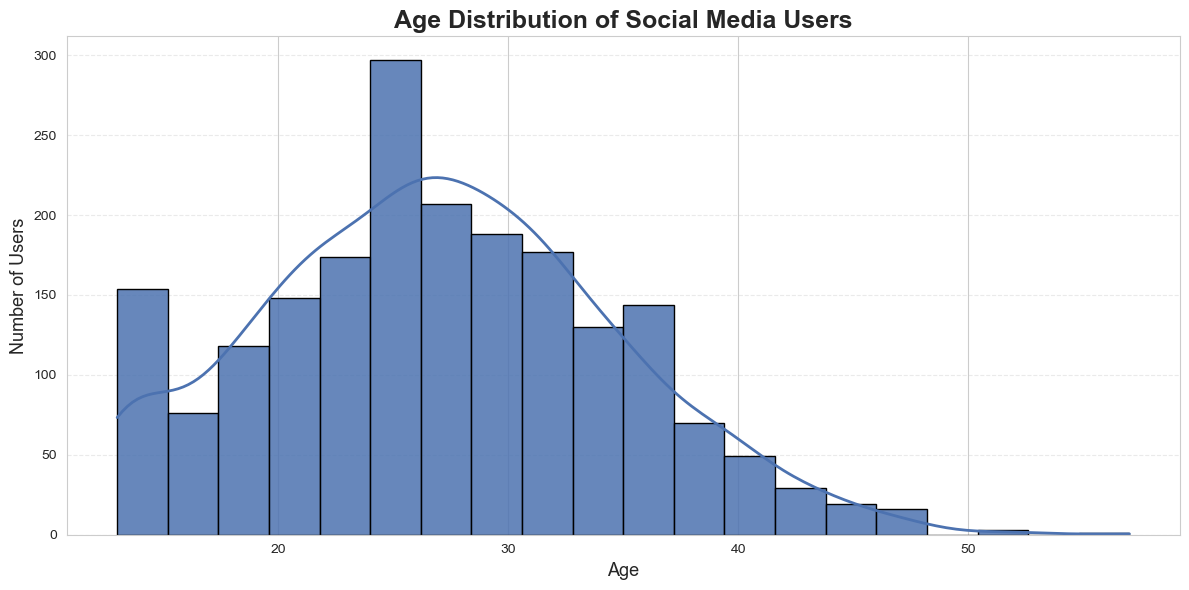

In [161]:
#  Distribution of Age
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x='age',
    bins=20,
    kde=True,
    color='#4C72B0',
    edgecolor='black',
    alpha=0.85,
    line_kws={'linewidth':2, 'color':'#FF6B6B'}
)

plt.title(
    'Age Distribution of Social Media Users',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Age', fontsize=13)
plt.ylabel('Number of Users', fontsize=13)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

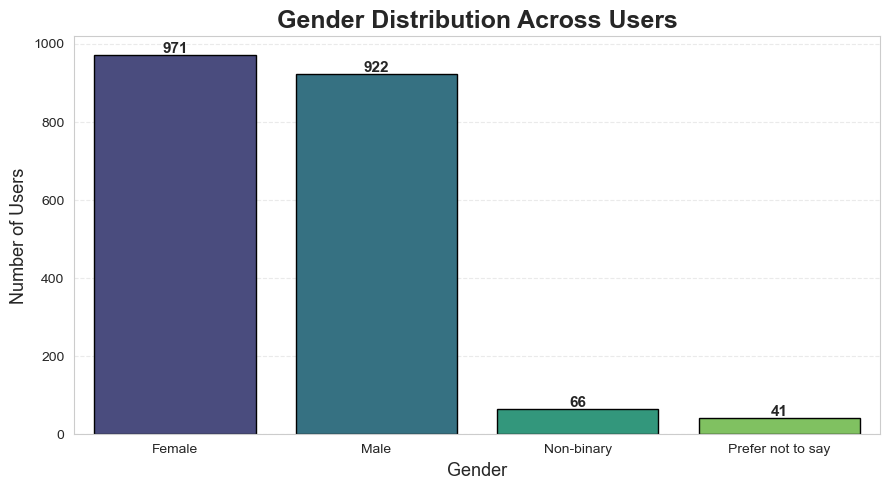

In [162]:
#  Gender Distribution

gender_counts = df['gender'].value_counts()

plt.figure(figsize=(9,5))

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values,
    palette='viridis',
    edgecolor='black'
)

plt.title(
    'Gender Distribution Across Users',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Gender', fontsize=13)
plt.ylabel('Number of Users', fontsize=13)

# Adding value labels on bars
for index, value in enumerate(gender_counts.values):
    plt.text(
        index,
        value + 5,
        str(value),
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

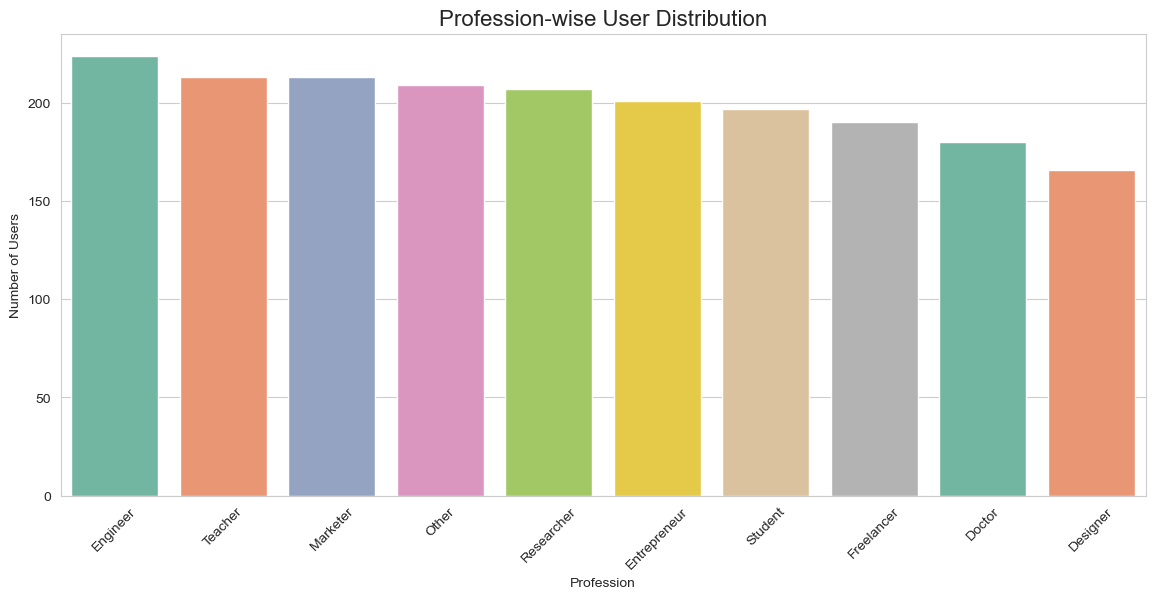

In [163]:

#  Profession Distribution

profession_counts = df['profession'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(14,6))

sns.barplot(
    x=profession_counts.index,
    y=profession_counts.values,
    palette='Set2'
)

plt.title('Profession-wise User Distribution', fontsize=16)
plt.xlabel('Profession')
plt.ylabel('Number of Users')

plt.xticks(rotation=45)

plt.show()

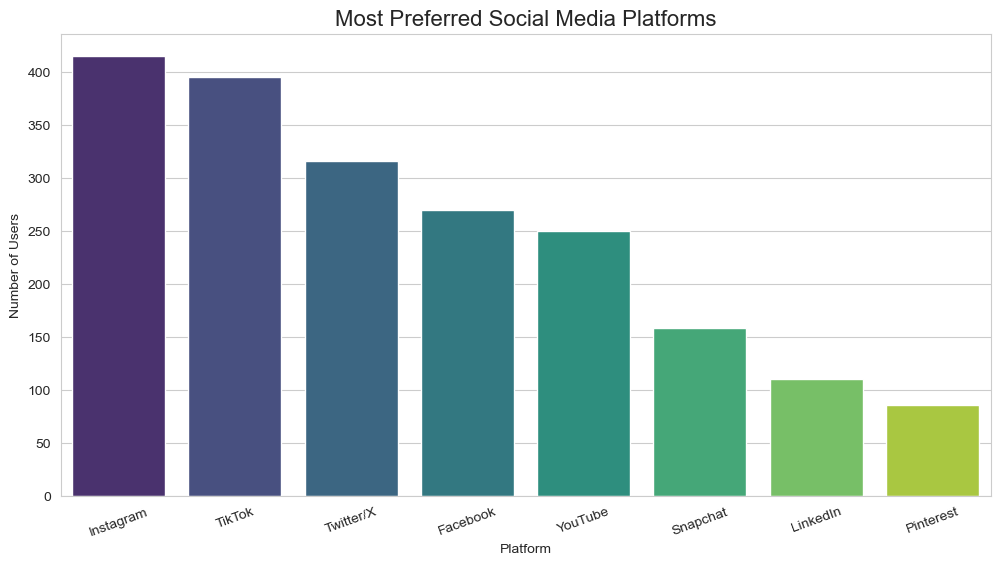

In [164]:
#  Most Preferred Social Media Platforms

platform_counts = df['primary_platform'].value_counts()

plt.figure(figsize=(12,6))

sns.barplot(
    x=platform_counts.index,
    y=platform_counts.values,
    palette='viridis'
)

plt.title('Most Preferred Social Media Platforms', fontsize=16)
plt.xlabel('Platform')
plt.ylabel('Number of Users')

plt.xticks(rotation=20)

plt.show()


#  Key Observations 
Observations:

1. The age distribution helps identify which generation
   dominates social media consumption patterns.

2. Gender distribution reveals whether platform engagement
   is balanced or skewed toward specific demographics.

3. Profession-wise analysis helps uncover:
   - Which user groups spend more time online
   - Which occupations are more digitally active

4. Platform preference analysis highlights:
   - Which platforms attract maximum users
   - Potential differences in user ecosystems

5. These foundational insights establish the demographic
   and behavioral context required before analyzing:
   
   - engagement behavior
   - mental health patterns
   - notification impact
   - user segmentation


## Measuring Digital Attention: How Much Time Are Users Really Spending Online?

Social media platforms compete for one thing more valuable than money:

Human attention.

Every extra minute spent scrolling increases:

engagement,
ad exposure,
content consumption,
and platform dependency.

But user activity is not uniform.

Some users casually check apps a few times a day, while others spend hours continuously consuming content across multiple sessions.

In this section, we will analyze:

Daily social media usage hours
Session frequency
Average session duration
Peak usage timings
Platform-wise attention patterns

The objective is to understand:

## Which behaviors indicate normal engagement — and which begin to resemble digital overconsumption?

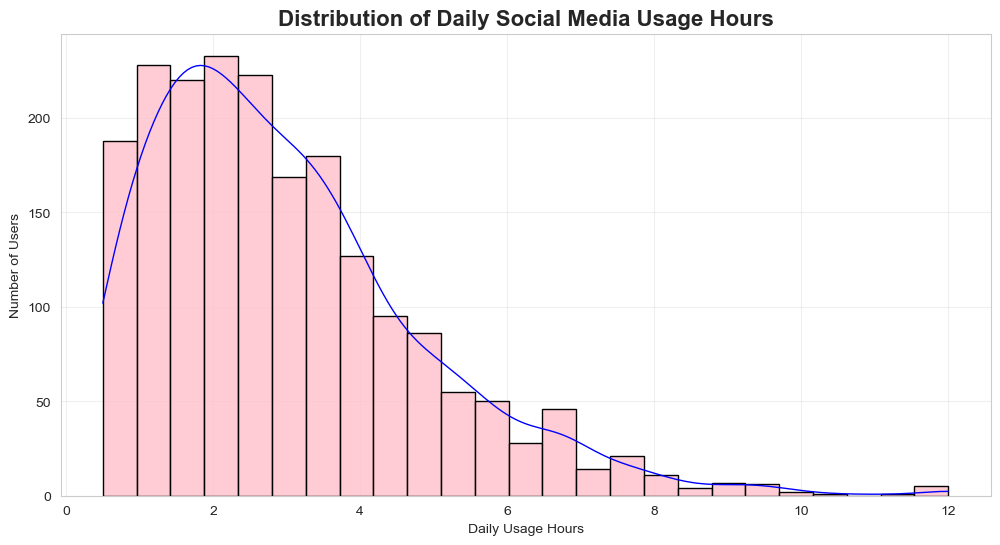

In [165]:
#  Distribution of Daily Usage Hours

plt.figure(figsize=(12,6))

ax = sns.histplot(
    df['daily_usage_hours'],
    bins=25,
    kde=True,
    color='pink',
    edgecolor='black',
    alpha=0.8
)

# Change KDE line color manually
ax.lines[0].set_color('blue')
ax.lines[0].set_linewidth(1)

plt.title('Distribution of Daily Social Media Usage Hours', fontsize=16, fontweight='bold')
plt.xlabel('Daily Usage Hours')
plt.ylabel('Number of Users')

plt.grid(alpha=0.3)

plt.show()

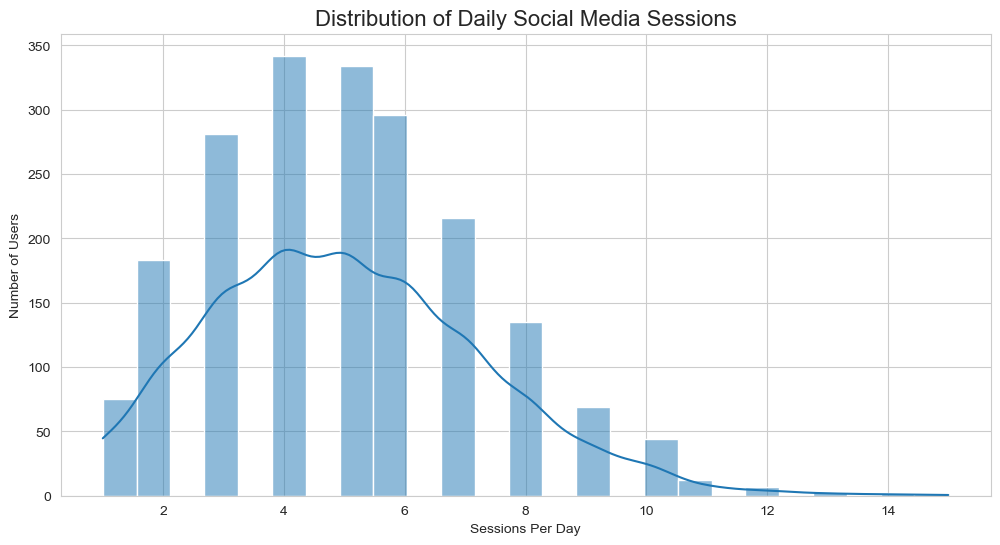

In [166]:
#  Sessions Per Day Distribution

plt.figure(figsize=(12,6))

sns.histplot(df['sessions_per_day'], bins=25, kde=True)

plt.title('Distribution of Daily Social Media Sessions', fontsize=16)
plt.xlabel('Sessions Per Day')
plt.ylabel('Number of Users')

plt.show()

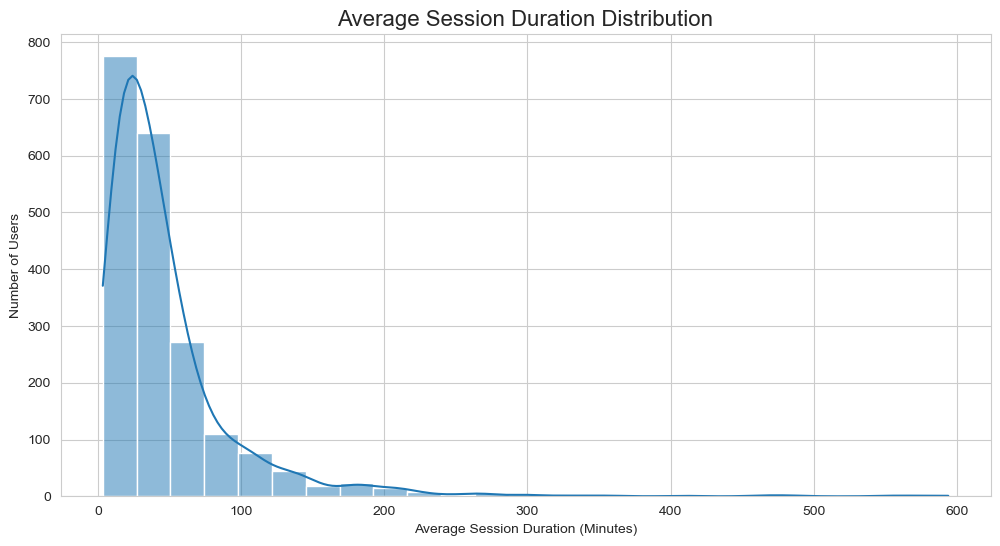

In [167]:
#  Average Session Duration Analysis

plt.figure(figsize=(12,6))

sns.histplot(df['avg_session_duration_min'], bins=25, kde=True)

plt.title('Average Session Duration Distribution', fontsize=16)
plt.xlabel('Average Session Duration (Minutes)')
plt.ylabel('Number of Users')

plt.show()

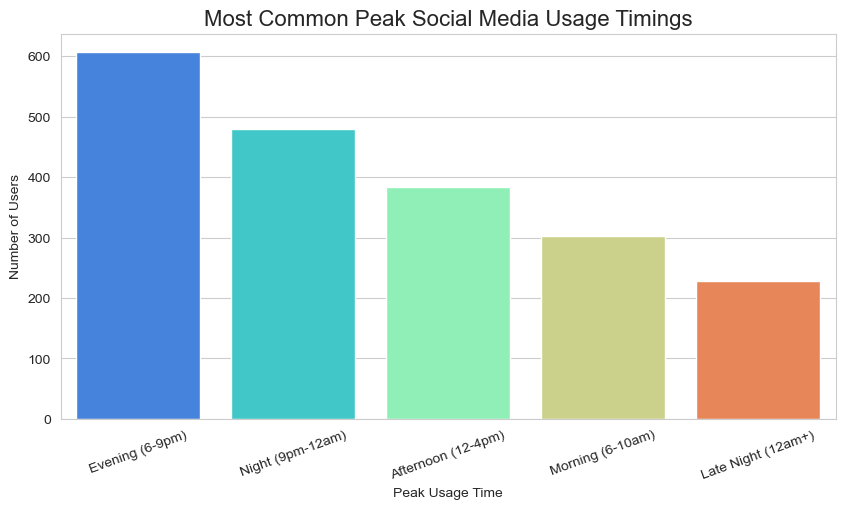

In [168]:
#  Peak Usage Time Analysis

peak_usage_counts = df['peak_usage_time'].value_counts()

plt.figure(figsize=(10,5))

sns.barplot(
    x=peak_usage_counts.index,
    y=peak_usage_counts.values,
    palette='rainbow'
)

plt.title('Most Common Peak Social Media Usage Timings', fontsize=16)
plt.xlabel('Peak Usage Time')
plt.ylabel('Number of Users')

plt.xticks(rotation=20)

plt.show()

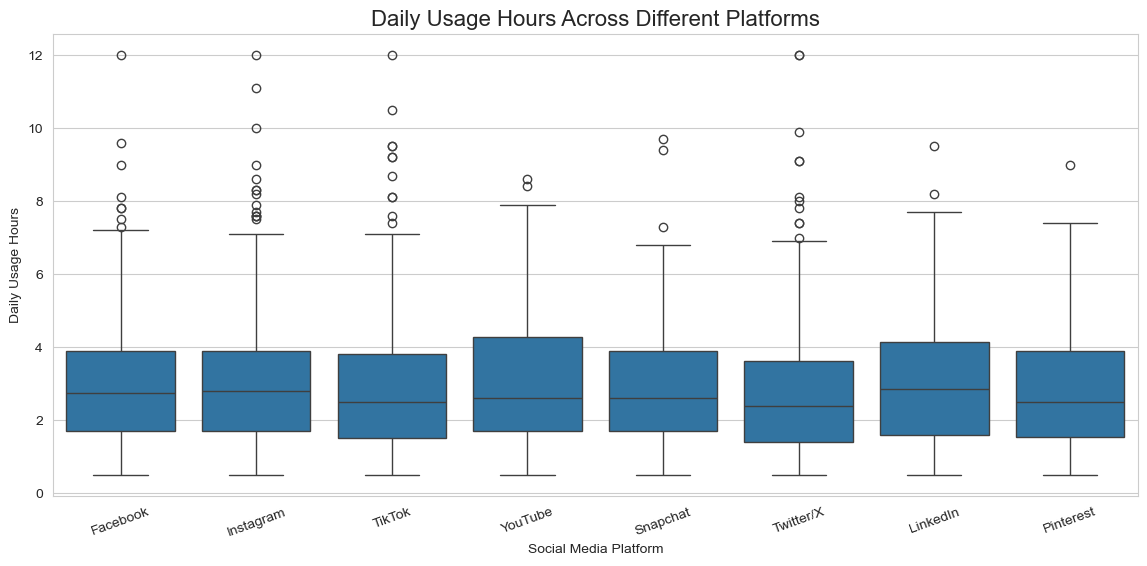

In [169]:
#  Platform-wise Daily Usage Analysis

plt.figure(figsize=(14,6))

sns.boxplot(
    x='primary_platform',
    y='daily_usage_hours',
    data=df
)

plt.title('Daily Usage Hours Across Different Platforms', fontsize=16)
plt.xlabel('Social Media Platform')
plt.ylabel('Daily Usage Hours')

plt.xticks(rotation=20)

plt.show()

#  Key Observations

1. Daily usage hour distribution helps identify:
   - average attention consumption
   - heavy usage behavior
   - potential addiction patterns

2. Sessions per day reveal how frequently users
   return to social media platforms.

3. Average session duration helps distinguish:
   - quick-check users
   - deep engagement users

4. Peak usage timing analysis can indicate:
   - when users are most vulnerable to engagement
   - high activity windows for platforms

5. Platform-wise usage comparison highlights:
   - which platforms retain users longer
   - which platforms encourage repeated usage

6. Together, these metrics provide a strong foundation
   for understanding digital attention economics
   and user engagement behavior.


#  From Scrolling to Interaction: Understanding User Engagement Behavior

Time spent on a platform tells only part of the story.

The real question is:

Are users actively participating — or just endlessly consuming content?

In today’s social media ecosystem, engagement has become the core currency of digital platforms.

Every:

* like,
* comment,
* share,
* direct message,
and post

acts as a signal of user involvement, platform stickiness, and content influence.

But not all engagement is equal.

Some users passively scroll for hours without interacting, while others actively:

* participate in discussions,
* amplify content,
* build communities,
and influence platform activity.

In this section, we will analyze key engagement metrics to uncover:

* how users interact with platforms,
* what behaviors indicate high engagement,
* and which activity patterns separate creators from consumers.

The objective is to move beyond screen time and answer a more important question:

What does meaningful engagement actually look like in the digital world?

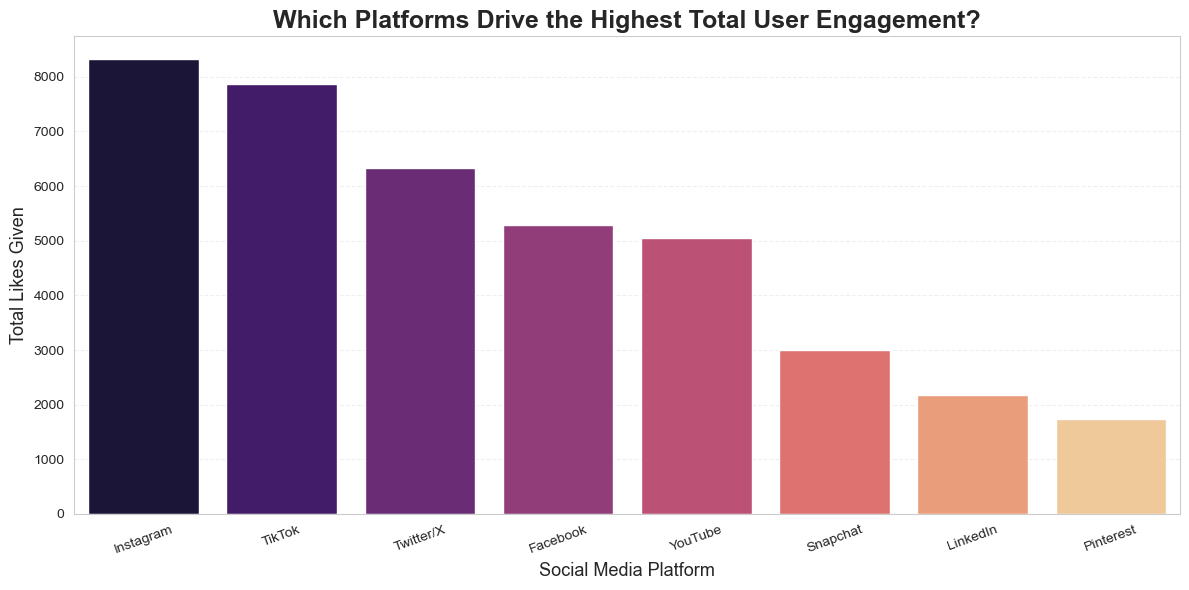

In [170]:

#  Total Likes Generated by Each Platform

likes_platform = (
    df.groupby('primary_platform')['likes_given_per_day']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=likes_platform.index,
    y=likes_platform.values,
    palette='magma'
)

plt.title(
    'Which Platforms Drive the Highest Total User Engagement?',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Social Media Platform', fontsize=13)
plt.ylabel('Total Likes Given', fontsize=13)

plt.xticks(rotation=20)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

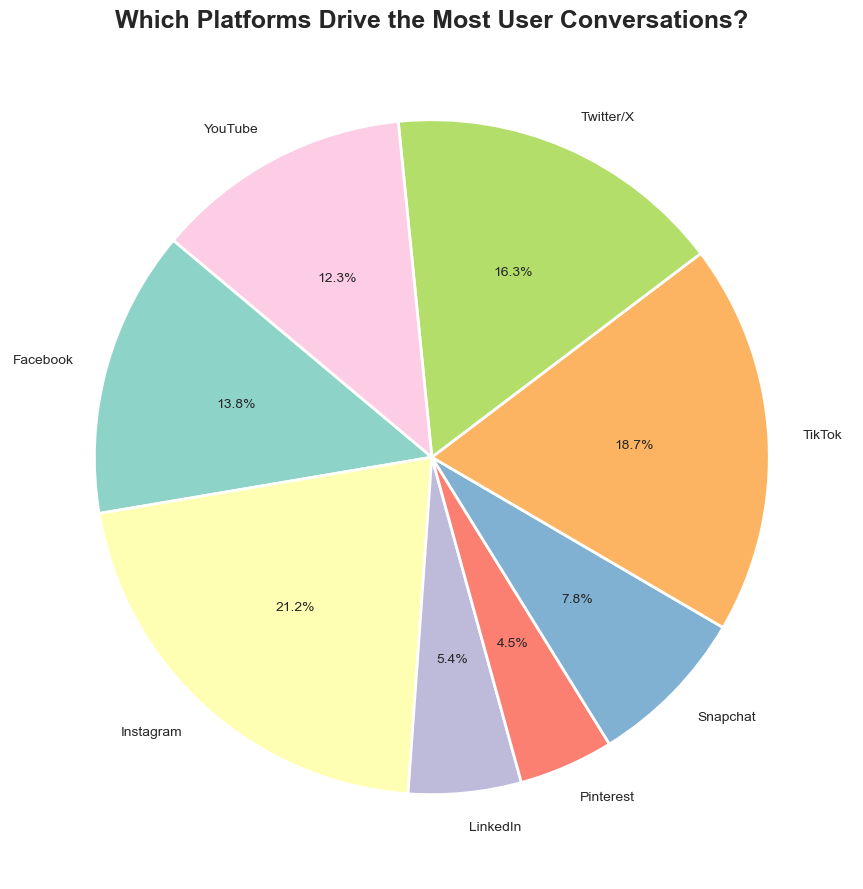

In [171]:
#  Platform-wise Comment Contribution

comments_platform = (
    df.groupby('primary_platform')['comments_per_day']
    .sum()
)

plt.figure(figsize=(9,9))

colors = sns.color_palette('Set3')

plt.pie(
    comments_platform.values,
    labels=comments_platform.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor':'white', 'linewidth':2}
)

plt.title(
    'Which Platforms Drive the Most User Conversations?',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

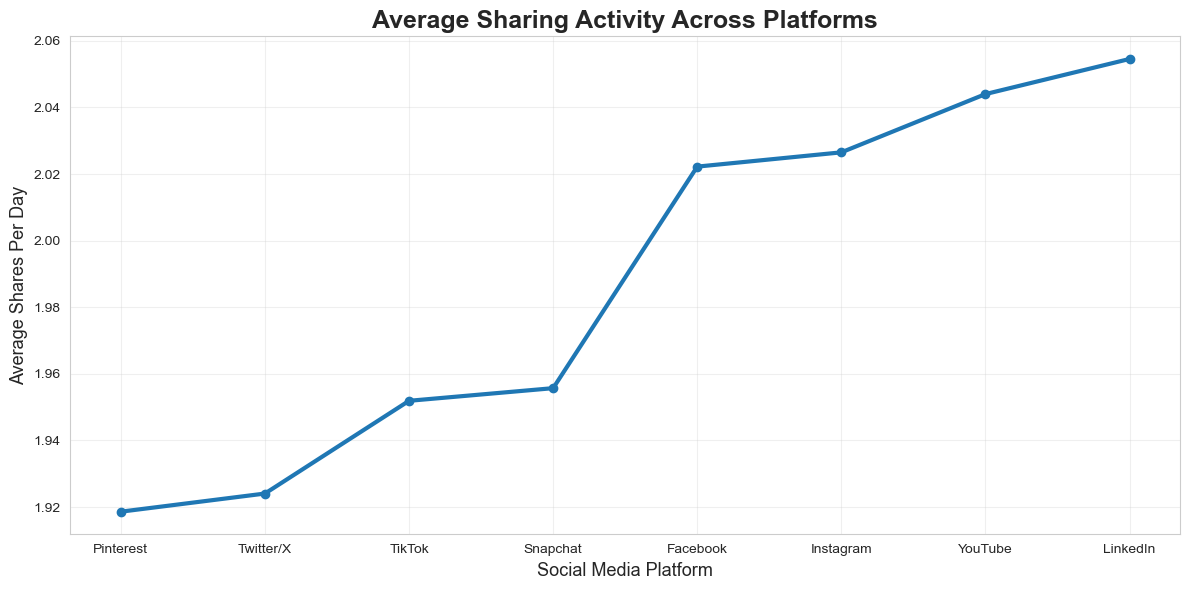

In [172]:

#  Platform-wise Shares Distribution

shares_platform = (
    df.groupby('primary_platform')['shares_per_day']
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12,6))

plt.plot(
    shares_platform.index,
    shares_platform.values,
    marker='o',
    linewidth=3
)

plt.title(
    'Average Sharing Activity Across Platforms',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Social Media Platform', fontsize=13)
plt.ylabel('Average Shares Per Day', fontsize=13)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

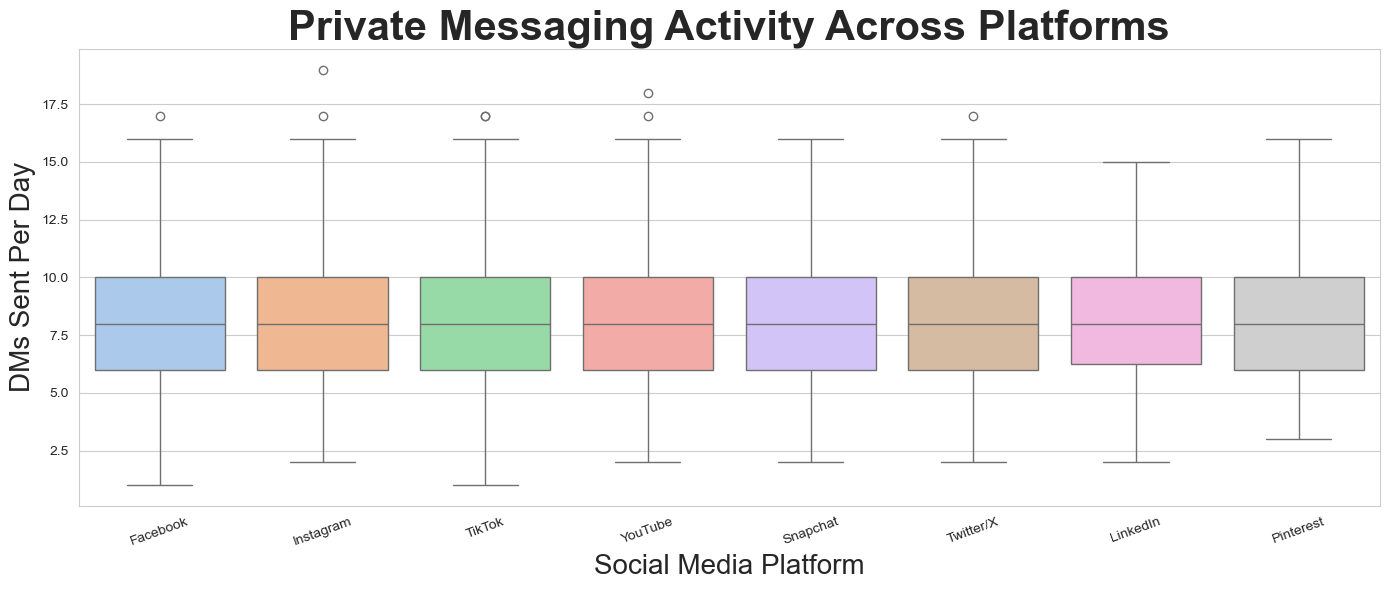

In [173]:

#  Platform-wise Private Messaging Behavior 

plt.figure(figsize=(14,6))

sns.boxplot(
    data=df,
    x='primary_platform',
    y='dms_sent_per_day',
    palette='pastel'
)

plt.title(
    'Private Messaging Activity Across Platforms',
    fontsize=30,
    fontweight='bold'
)

plt.xlabel('Social Media Platform', fontsize=20)
plt.ylabel('DMs Sent Per Day', fontsize=20)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## The Psychology of Social Media Usage

Social media platforms are designed to maximize attention.

But as engagement increases, an important question emerges:

Does higher digital interaction come at a psychological cost?

Modern platforms optimize for:

* retention,
* notifications,
* continuous scrolling,
* and repeated user activity.

While these mechanisms improve engagement metrics, they may also influence:

* sleep quality,
* screen-time dependency,
* mood,
* and overall mental wellbeing.

In this section, we will explore the relationship between:

* social media usage patterns,
* behavioral addiction signals,
* and self-reported mental health indicators.

The goal is not to diagnose users.

Instead, the objective is to understand:

## How digital behavior patterns may influence emotional and psychological wellbeing in highly connected online environments.

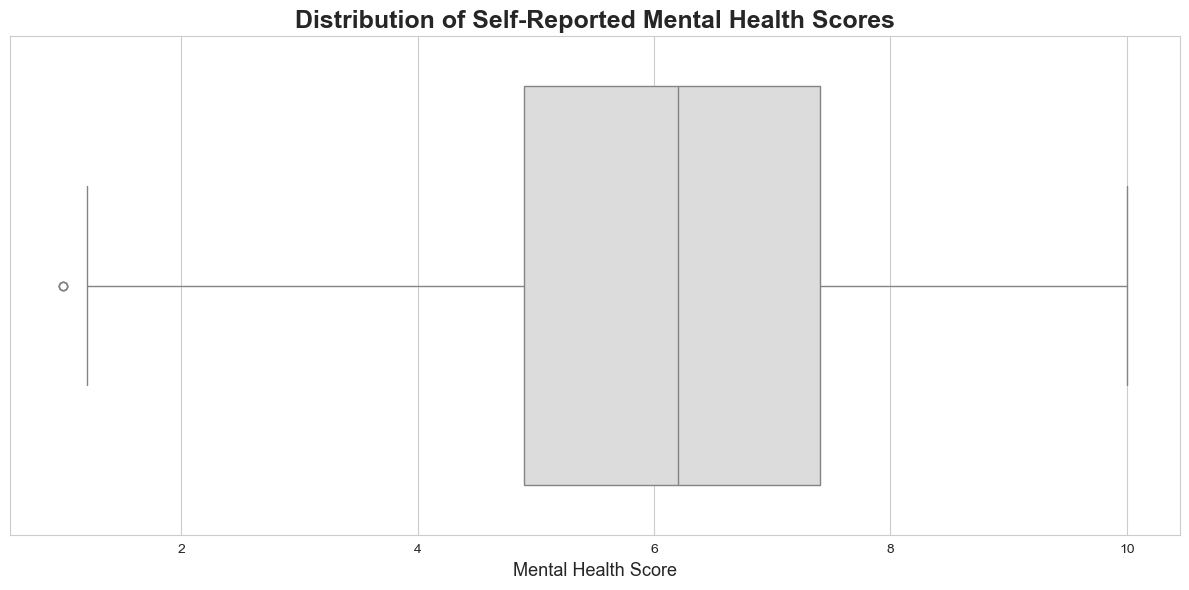

In [174]:
#  Mental Health Score Distribution


plt.figure(figsize=(12,6))

sns.boxplot(
    x=df['self_reported_mental_health_score'],
    palette='coolwarm'
)

plt.title(
    'Distribution of Self-Reported Mental Health Scores',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Mental Health Score', fontsize=13)

plt.tight_layout()
plt.show()

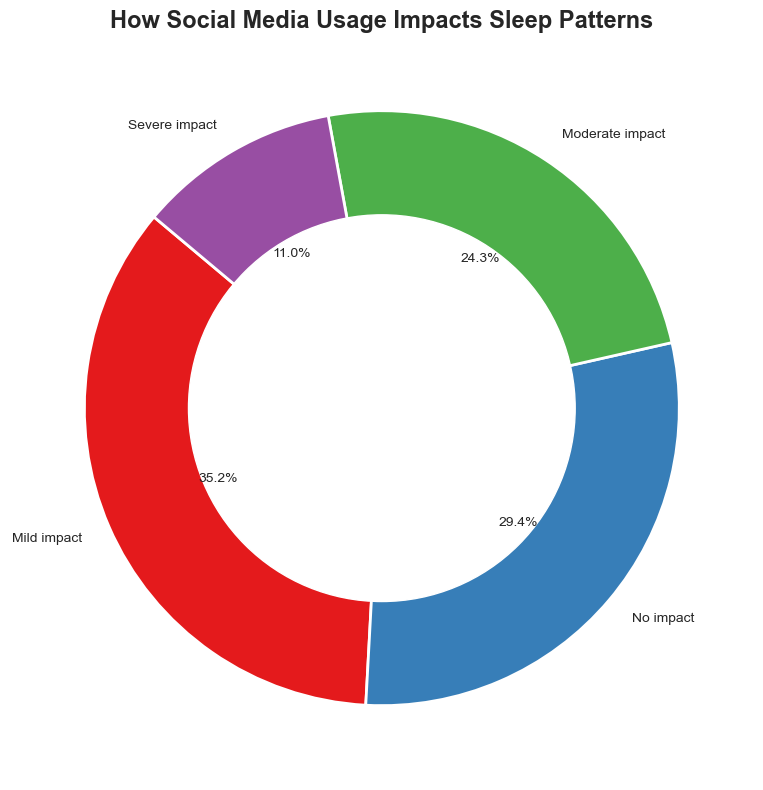

In [175]:
#  Sleep Disruption Analysis

sleep_counts = df['sleep_disruption'].value_counts()

plt.figure(figsize=(8,8))

colors = sns.color_palette('Set1')

plt.pie(
    sleep_counts.values,
    labels=sleep_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor':'white', 'linewidth':2}
)

centre_circle = plt.Circle((0,0),0.65,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title(
    'How Social Media Usage Impacts Sleep Patterns',
    fontsize=17,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

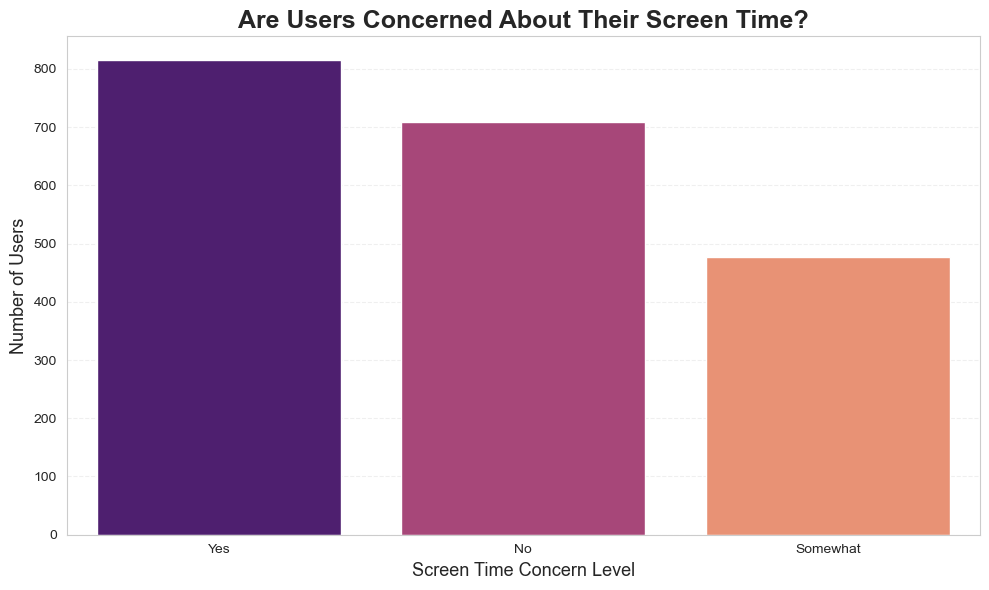

In [176]:
# 📌 Screen Time Concern Analysis

screen_time_counts = df['screen_time_concern'].value_counts()

plt.figure(figsize=(10,6))

sns.barplot(
    x=screen_time_counts.index,
    y=screen_time_counts.values,
    palette='magma'
)

plt.title(
    'Are Users Concerned About Their Screen Time?',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Screen Time Concern Level', fontsize=13)
plt.ylabel('Number of Users', fontsize=13)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

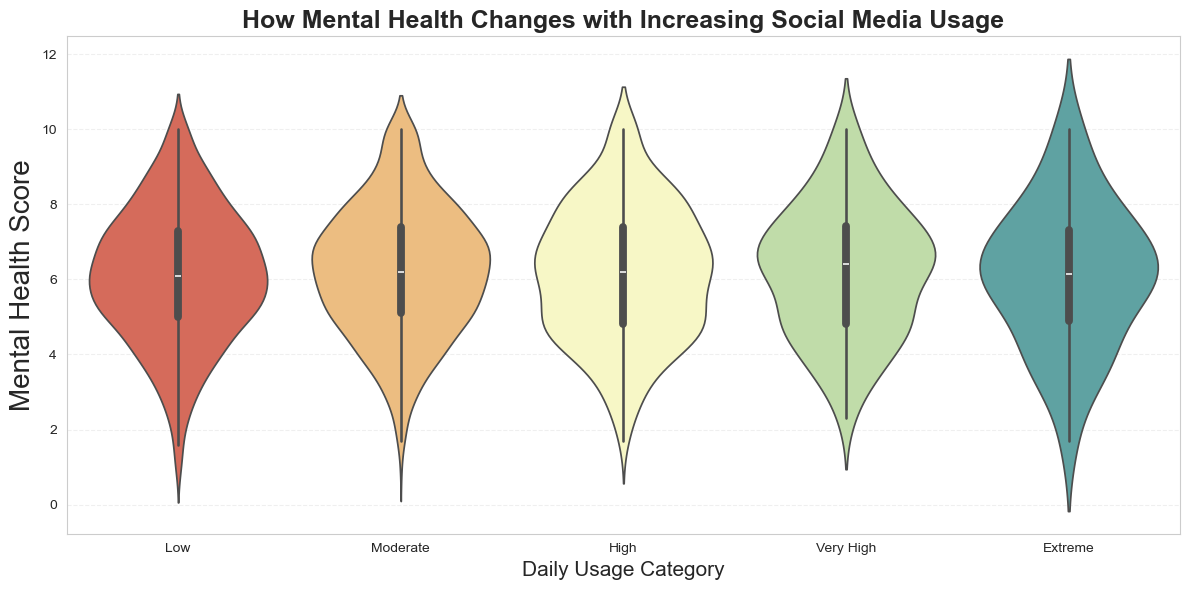

In [177]:
#  Daily Usage Hours vs Mental Health Score

# Creating Usage Categories
df['usage_category'] = pd.cut(
    df['daily_usage_hours'],
    bins=[0,2,4,6,8,12],
    labels=['Low','Moderate','High','Very High','Extreme']
)

plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x='usage_category',
    y='self_reported_mental_health_score',
    palette='Spectral'
)

plt.title(
    'How Mental Health Changes with Increasing Social Media Usage',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Daily Usage Category', fontsize=15)
plt.ylabel('Mental Health Score', fontsize=20)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

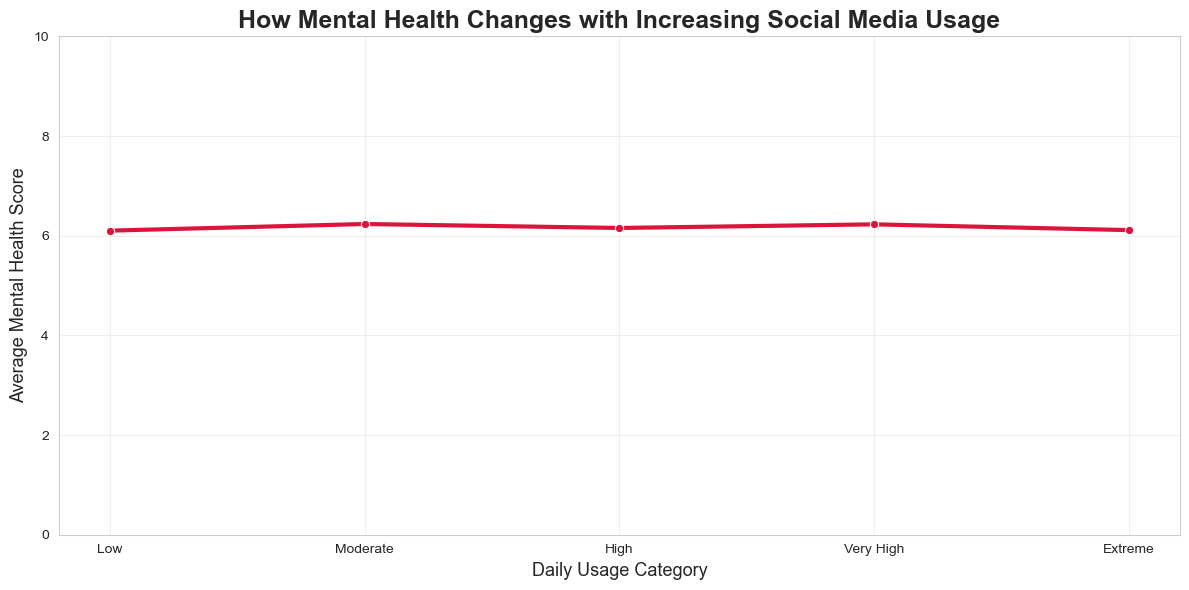

In [178]:
#  Mental Health Score vs Social Media Usage

# Creating Usage Categories
df['usage_category'] = pd.cut(
    df['daily_usage_hours'],
    bins=[0,2,4,6,8,12],
    labels=['Low','Moderate','High','Very High','Extreme']
)

# Calculating Average Mental Health Score
mental_health_avg = (
    df.groupby('usage_category')['self_reported_mental_health_score']
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=mental_health_avg,
    x='usage_category',
    y='self_reported_mental_health_score',
    marker='o',
    linewidth=3,
    color='crimson'
)

plt.title(
    'How Mental Health Changes with Increasing Social Media Usage',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Daily Usage Category', fontsize=13)
plt.ylabel('Average Mental Health Score', fontsize=13)

# Proper Y-axis scaling
plt.ylim(0,10)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

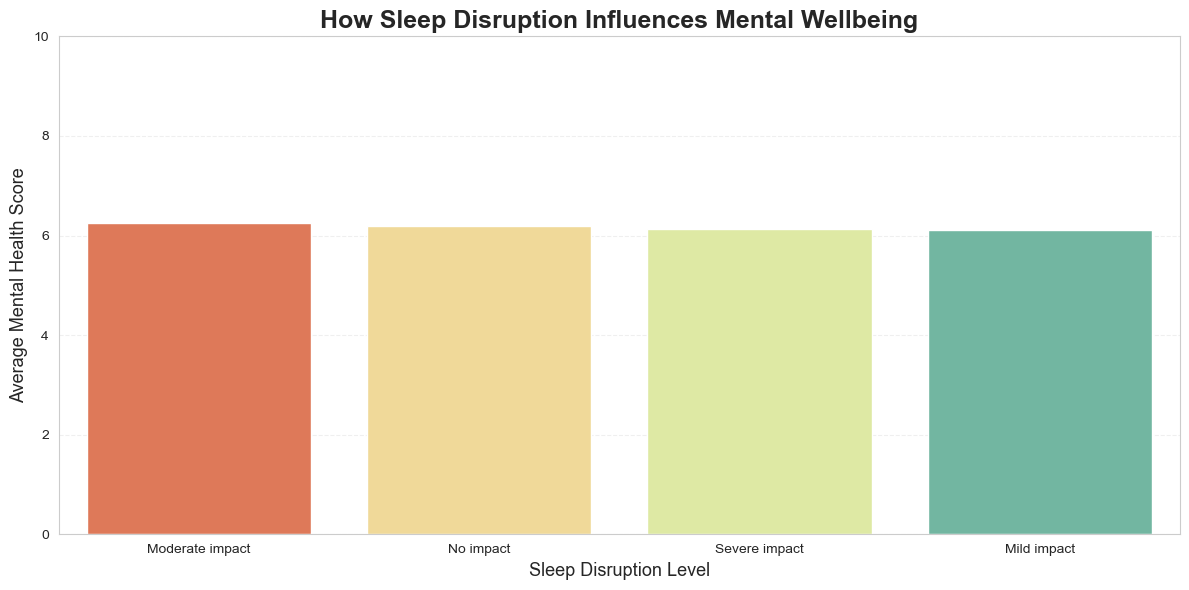

In [179]:

#  Sleep Disruption vs Mental Health Score


sleep_mental = (
    df.groupby('sleep_disruption')['self_reported_mental_health_score']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=sleep_mental.index,
    y=sleep_mental.values,
    palette='Spectral'
)

plt.title(
    'How Sleep Disruption Influences Mental Wellbeing',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Sleep Disruption Level', fontsize=13)
plt.ylabel('Average Mental Health Score', fontsize=13)

plt.ylim(0,10)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

##  Key Insight: Mental Health Patterns Remain Surprisingly Stable Across User Groups

One of the most interesting findings from the analysis is not a dramatic decline in mental wellbeing — but rather the absence of a strong variation.

Despite differences in:

* daily usage hours,
* sleep disruption levels,
* and engagement intensity,

the average self-reported mental health scores remain relatively stable across user groups.

This suggests that within this dataset:

social media usage alone may not be a strong standalone indicator of mental wellbeing.

The result highlights an important principle in behavioral analytics:

High engagement does not automatically translate into poor mental health outcomes.

Instead, psychological wellbeing is likely influenced by a combination of factors beyond screen time alone, such as:

* lifestyle,
* personal habits,
* emotional resilience,
* and the quality of online interactions.

This also demonstrates an important aspect of real-world data analysis:

meaningful insights come from accurately interpreting the data — not forcing expected narratives onto it.

#  Notifications, Attention, and the Battle for User Retention

Modern social media platforms are built around one core objective:

bringing users back as frequently as possible.

Notifications play a major role in this strategy.

Every:

* message alert,
* like notification,
* comment update,
* or trending content prompt

acts as a trigger designed to recapture user attention.

But this raises important behavioral questions:

* Do frequent notifications actually increase platform usage?
* Are highly notified users spending significantly more time online?
* Does constant engagement create higher screen-time concern?
* And how strongly are notifications linked to digital dependency patterns?

In this section, we will explore how notification behavior influences:

* user attention,
* engagement frequency,
* and screen-time awareness.

The goal is to understand:

whether notifications simply inform users — or actively shape digital behavior patterns.



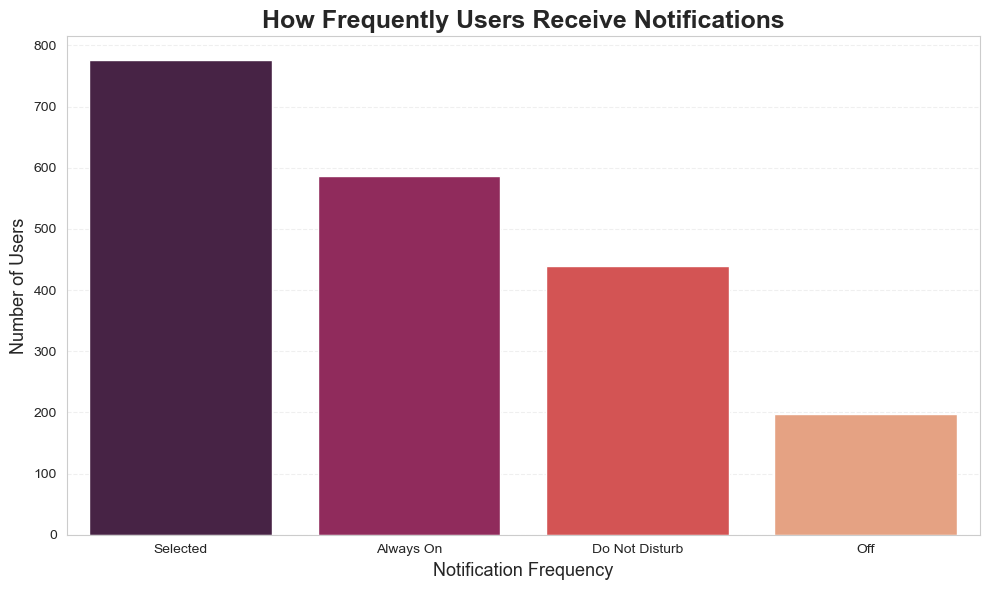

In [180]:
#  Notification Frequency Distribution

notification_counts = df['notification_frequency'].value_counts()

plt.figure(figsize=(10,6))

sns.barplot(
    x=notification_counts.index,
    y=notification_counts.values,
    palette='rocket'
)

plt.title(
    'How Frequently Users Receive Notifications',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Notification Frequency', fontsize=13)
plt.ylabel('Number of Users', fontsize=13)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

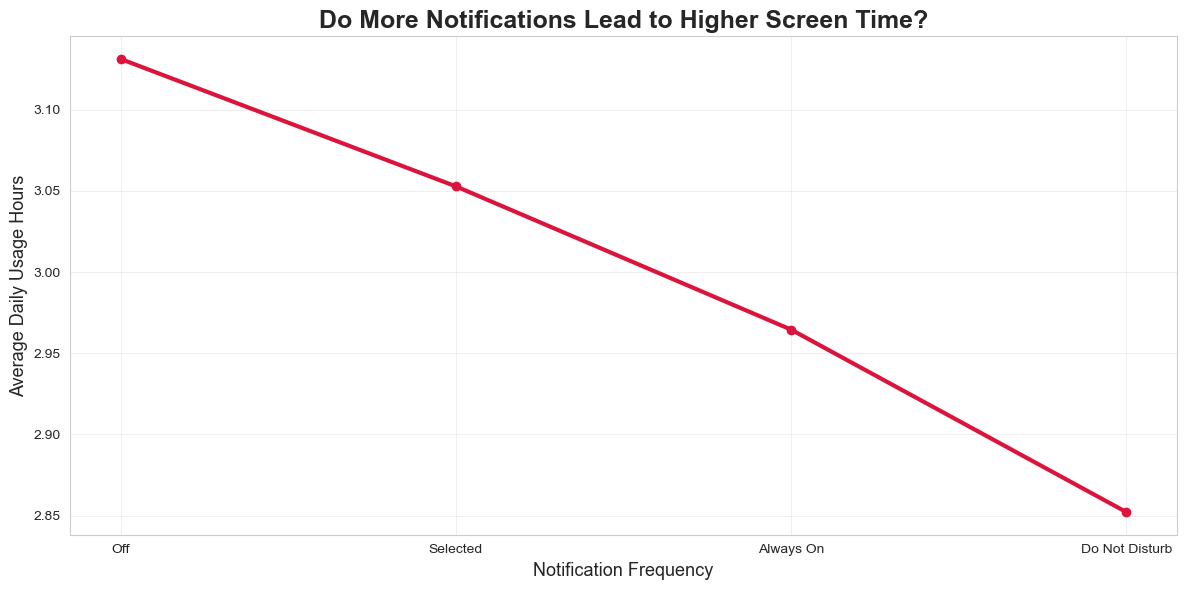

In [181]:
#  Average Usage Hours by Notification Frequency

usage_notification = (
    df.groupby('notification_frequency')['daily_usage_hours']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

plt.plot(
    usage_notification.index,
    usage_notification.values,
    marker='o',
    linewidth=3,
    color='crimson'
)

plt.title(
    'Do More Notifications Lead to Higher Screen Time?',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Notification Frequency', fontsize=13)
plt.ylabel('Average Daily Usage Hours', fontsize=13)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

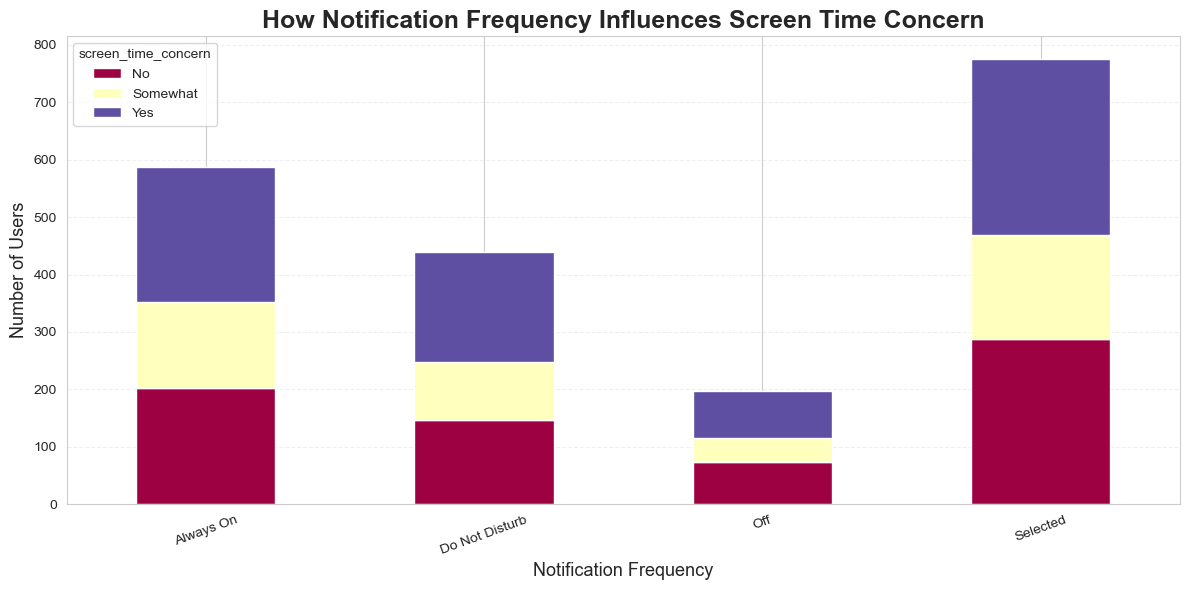

In [182]:
#  Screen Time Concern by Notification Frequency

concern_notification = pd.crosstab(
    df['notification_frequency'],
    df['screen_time_concern']
)

concern_notification.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    colormap='Spectral'
)

plt.title(
    'How Notification Frequency Influences Screen Time Concern',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Notification Frequency', fontsize=13)
plt.ylabel('Number of Users', fontsize=13)

plt.xticks(rotation=20)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Privacy, Visibility, and User Behavior in the Digital World

Social media platforms thrive on visibility.

The more users share:

* personal updates,
* interests,
* activity patterns,
*and interactions,

the more platforms can optimize:

* engagement,
* recommendations,
* advertising,
* and content personalization.

But not all users behave the same way online.

Some users prefer:

* public visibility,
* open interactions,
*and highly active social participation,

while others prioritize:

* privacy,
* controlled access,
and limited exposure.

This creates an important behavioral question:

## Does privacy preference influence how users engage with social media platforms?

In this section, we will explore how different privacy settings relate to:

* engagement activity,
* posting behavior,
and overall platform participation.

The objective is to understand:

## whether highly visible users behave differently from privacy-conscious users in digital ecosystems.

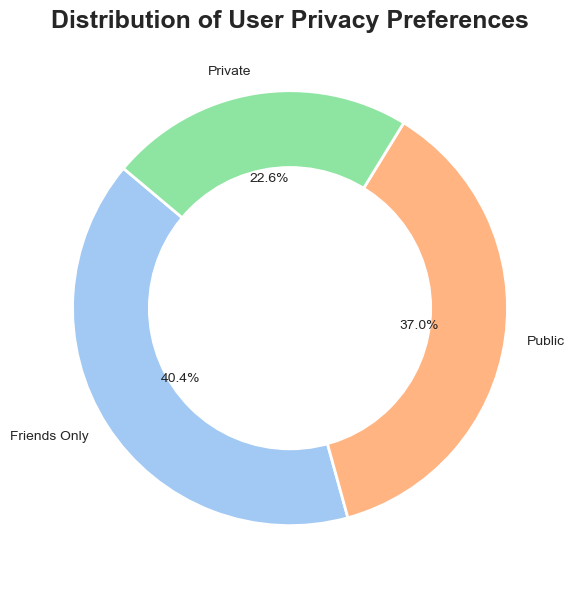

In [183]:

#  Privacy Setting Distribution

privacy_counts = df['privacy_setting'].value_counts()

plt.figure(figsize=(9,6))

colors = sns.color_palette('pastel')

plt.pie(
    privacy_counts.values,
    labels=privacy_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor':'white', 'linewidth':2}
)

# Donut Hole
centre_circle = plt.Circle((0,0),0.65,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title(
    'Distribution of User Privacy Preferences',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## User Segmentation & Behavioral Clustering

Until this point, the analysis focused on understanding overall user behavior patterns across social media platforms.

However, averages alone often hide the most important insights.

Not every user interacts with social media in the same way.

Some users:

* actively create content,
* some engage heavily through likes and comments,
* while others spend long hours consuming content with minimal interaction.

To uncover these hidden behavioral patterns, we now move beyond traditional analysis and apply:

## Unsupervised Machine Learning

Using clustering techniques, users will be grouped based on similarities in:

* engagement behavior,
* platform activity,
* session patterns,
and usage intensity.

The goal of this section is to identify distinct digital user personas such as:

* highly active users,
* passive consumers,
* content creators,
and heavy engagement users.

Rather than analyzing users one by one, clustering helps reveal:

How different behavioral communities naturally exist within social media ecosystems.

In [184]:
#  Importing Clustering Libraries

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [185]:
#  Selecting Features for Clustering

clustering_features = df[[
    'daily_usage_hours',
    'sessions_per_day',
    'avg_session_duration_min',
    'likes_given_per_day',
    'comments_per_day',
    'shares_per_day',
    'dms_sent_per_day',
    'posts_per_week'
]]

In [186]:
#  Feature Scaling

scaler = StandardScaler()
scaled_features = scaler.fit_transform(clustering_features)

In [187]:
#  Finding Optimal Number of Clusters

inertia = []

K = range(1,11)

for k in K:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    kmeans.fit(scaled_features)
    
    inertia.append(kmeans.inertia_)

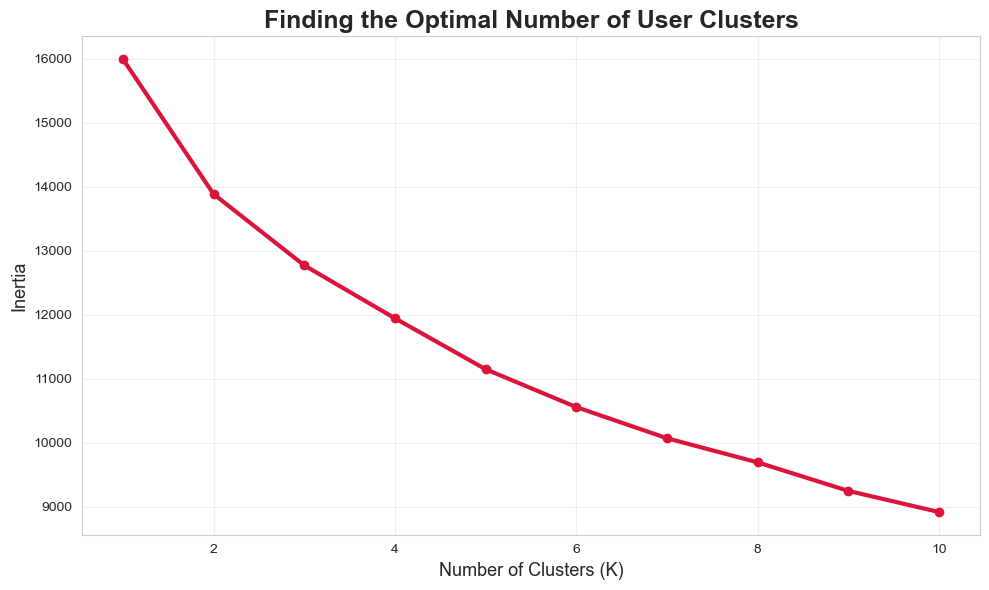

In [188]:
#  Elbow Method Visualization


plt.figure(figsize=(10,6))

plt.plot(
    K,
    inertia,
    marker='o',
    linewidth=3,
    color='crimson'
)

plt.title(
    'Finding the Optimal Number of User Clusters',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Number of Clusters (K)', fontsize=13)
plt.ylabel('Inertia', fontsize=13)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Why Finding the Right Number of Clusters Matters

Before segmenting users into behavioral groups, it is important to determine:

How many meaningful user personas actually exist within the data.

The Elbow Method helps identify the optimal number of clusters by measuring how effectively users are grouped based on similarities in:

* Engagement,
* Activity patterns,
* Session behavior,
* and usage intensity.

The goal is to avoid:

* oversimplifying users into very broad groups,
or
* creating too many unnecessary micro-segments.

This approach is widely used in real-world platforms for:

* Customer segmentation,
* Personalized recommendations,
* Targeted advertising,
and behavior-driven product strategies.

For example:

* Netflix segments viewers based on watching behavior,
* Spotify identifies listening patterns for recommendations,
while social media platforms group users based on interaction and engagement activity.

In this project, clustering helps transform raw social media activity into meaningful digital user personas that can reveal hidden behavioral patterns within the platform ecosystem.

In [189]:
#  Applying KMeans Clustering

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(scaled_features)

In [190]:
#  Reducing Dimensions Using PCA
pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

pca_df = pd.DataFrame(
    data=pca_features,
    columns=['PCA1', 'PCA2']
)

pca_df['Cluster'] = df['Cluster']

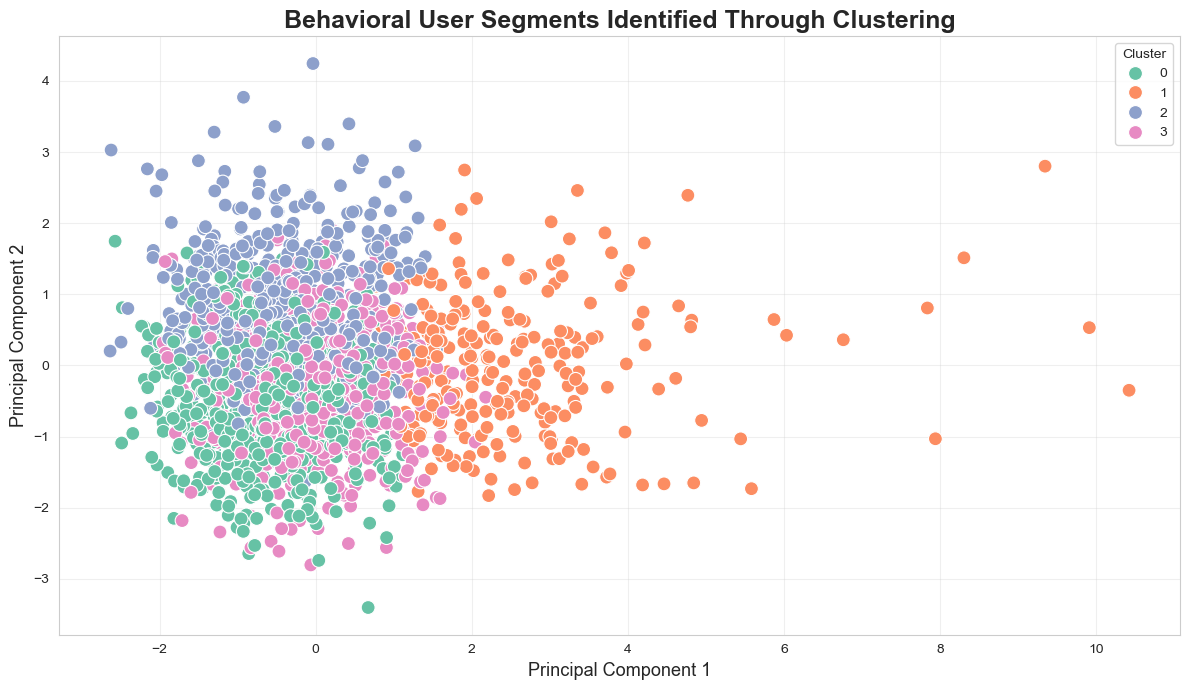

In [191]:
#  Visualizing User Clusters

plt.figure(figsize=(12,7))

sns.scatterplot(
    data=pca_df,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='Set2',
    s=100
)

plt.title(
    'Behavioral User Segments Identified Through Clustering',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Principal Component 1', fontsize=13)
plt.ylabel('Principal Component 2', fontsize=13)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [193]:
#  Cluster-wise Behavioral Summary

cluster_summary = df.groupby('Cluster')[[
    'daily_usage_hours',
    'sessions_per_day',
    'avg_session_duration_min',
    'likes_given_per_day',
    'comments_per_day',
    'shares_per_day',
    'dms_sent_per_day',
    'posts_per_week'
]].mean()

cluster_summary

,daily_usage_hours,sessions_per_day,avg_session_duration_min,likes_given_per_day,comments_per_day,shares_per_day,dms_sent_per_day,posts_per_week
Cluster,,,,,,,,
0,2.389308,5.781447,27.988994,17.687107,2.850629,1.555031,9.031447,2.298742
1,5.823372,3.022989,142.483908,19.302682,4.030651,1.819923,8.026820,2.957854
2,2.689842,5.535902,33.104904,22.651489,3.329247,2.465849,7.423818,4.217163
3,2.642669,4.552632,39.854511,19.821429,6.046992,2.077068,7.469925,2.417293


In [194]:
#  Assigning Meaningful Cluster Names
cluster_names = {
    0: 'Passive Scrollers',
    1: 'Heavy Consumers',
    2: 'Active Engagers',
    3: 'Conversational Users'
}

df['User Persona'] = df['Cluster'].map(cluster_names)

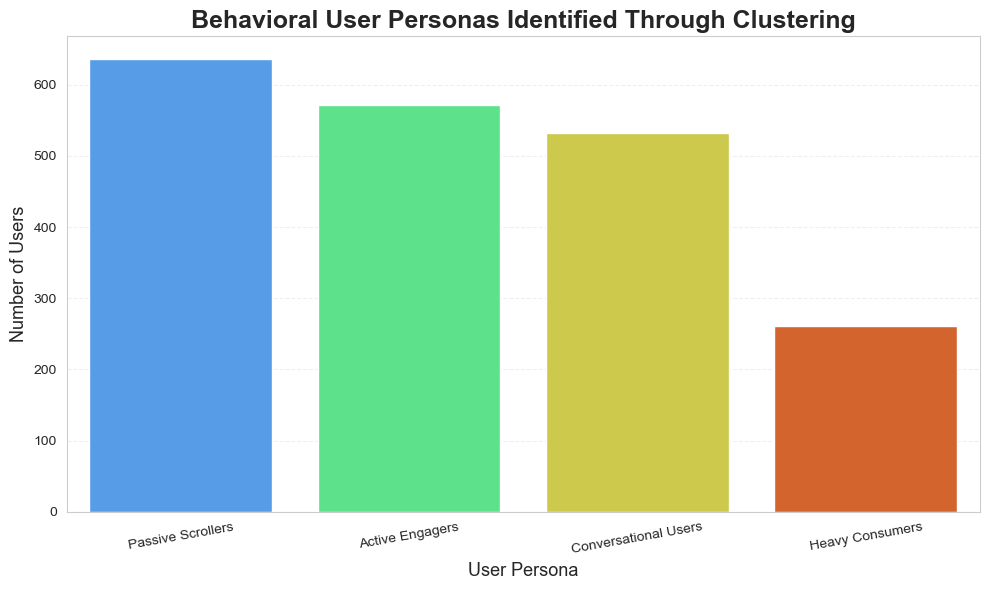

In [216]:
#  Distribution of User Personas

persona_counts = df['User Persona'].value_counts()

plt.figure(figsize=(10,6))

sns.barplot(
    x=persona_counts.index,
    y=persona_counts.values,
    palette='turbo'
)

plt.title(
    'Behavioral User Personas Identified Through Clustering',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('User Persona', fontsize=13)
plt.ylabel('Number of Users', fontsize=13)

plt.xticks(rotation=10)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

##  Correlation Analysis

While individual metrics provide isolated insights, correlation analysis helps uncover how different behavioral patterns are connected within the social media ecosystem.

This section helps identify relationships between:

* usage intensity,
* engagement activity,
* session behavior,
* and interaction patterns.

Correlation analysis is widely used in real-world analytics for:

* behavioral modeling,
* recommendation systems,
* feature selection,
* and user behavior prediction.

The heatmap below provides a quick overview of how user activities relate to one another.


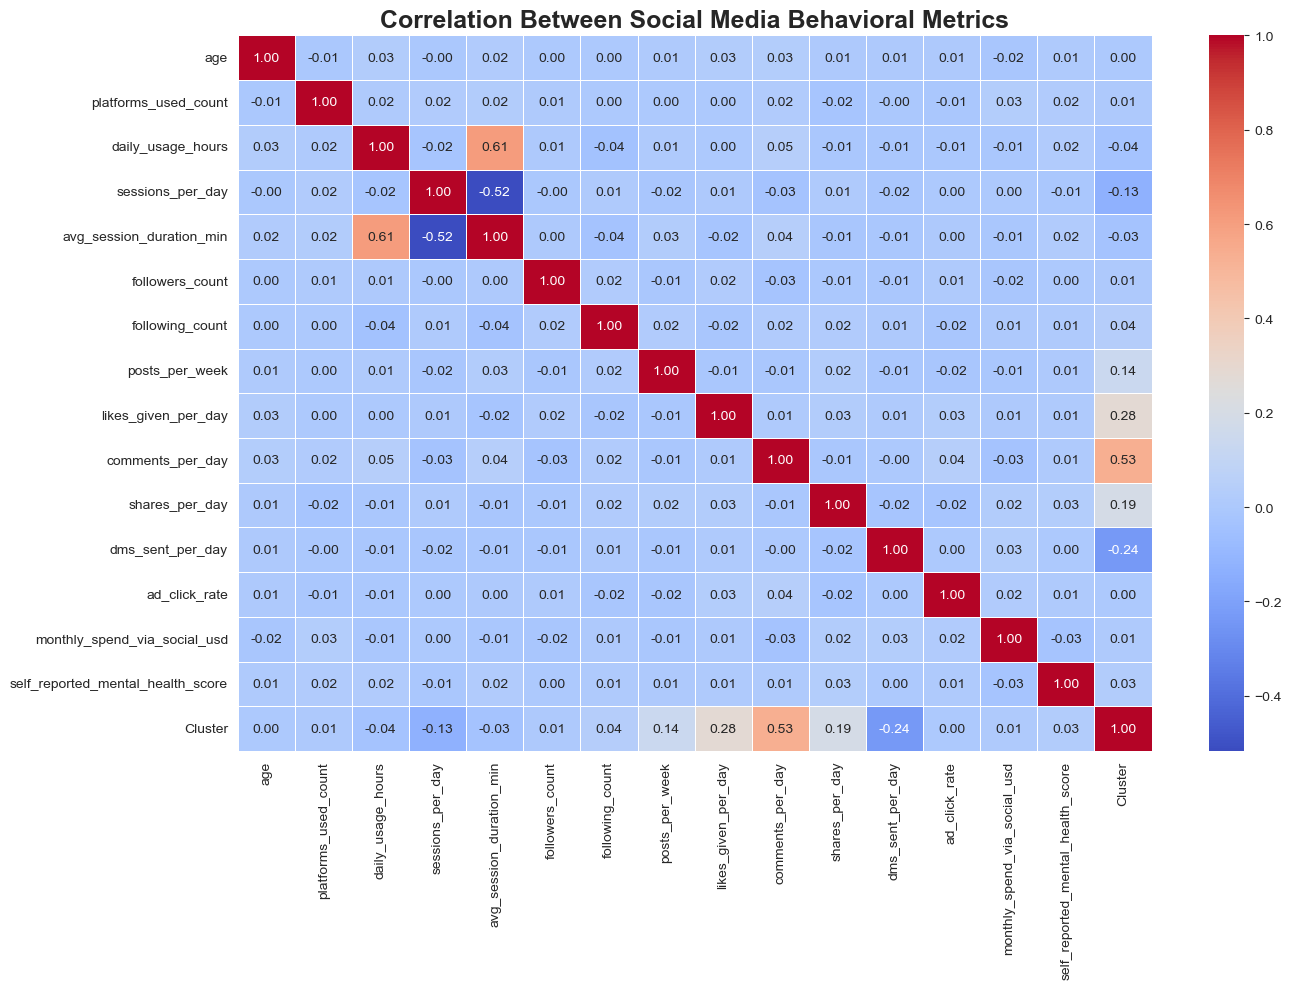

In [217]:
# Correlation Heatmap

correlation_matrix = df.select_dtypes(include='number').corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title(
    'Correlation Between Social Media Behavioral Metrics',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## Final Observations & Key Insights

This analysis explored how social media behavior varies across users based on:

* Engagement activity,
* Session behavior,
* Notification patterns,
and interaction intensity.

The dataset revealed that user behavior is highly diverse, with some users acting as passive consumers while others showed significantly higher engagement through likes, comments, posts, and conversations.

Notification frequency appeared to influence user attention and repeated platform activity more strongly than psychological indicators, while mental health patterns remained relatively stable across different usage groups.

# Behavioral Segmentation Using Machine Learning

Using clustering techniques, the project identified multiple behavioral user personas such as:

* Passive users,
* Active engagers,
* Conversational users,
and heavy content consumers.

# This demonstrates how machine learning can transform raw behavioral activity into meaningful user profiles and engagement insights.

# Real-World Relevance

Behavioral analytics and user segmentation are widely used by platforms like:

* Netflix
* Spotify
* Meta

for:

* Recommendation systems,
* Personalized experiences,
* Targeted engagement,
and user retention strategies.

# Conclusion

This project demonstrates how exploratory data analysis and unsupervised machine learning can be combined to uncover hidden behavioral patterns within social media ecosystems.

Rather than focusing only on visualizations, the analysis aimed to understand:

* Digital attention,
* Engagement behavior,
* Interaction patterns,
and user segmentation.

The result is a behavioral intelligence workflow that transforms raw social media activity into meaningful and actionable user insights.

# Analysis By
Shubham Anant Kulkarni, 

LinkedIn: https://www.linkedin.com/in/shubhamakulkarni-data-analyst/